In [3]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df=pd.read_csv('fsw_clean_dataset.csv')

In [4]:
X = df[['D','V','N','HeatInput']]
y = df['Yield']

In [5]:
print(X.shape)
print(y.shape)

(550, 4)
(550,)


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [8]:
print(X.shape)
print(y.shape)

(550, 4)
(550,)


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [10]:
print(X_train.shape)
print(X_test.shape)

(440, 4)
(110, 4)


In [11]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [12]:
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns)

In [13]:
X_train_scaled.head()

,D,V,N,HeatInput
0,0.192143,1.332087,1.389019,-0.127900
1,0.571105,0.648686,1.086127,0.328887
2,1.018968,-0.205564,-0.159095,0.769551
3,-1.495959,1.229577,-0.411505,-1.191831
4,0.329947,1.263747,1.506811,0.024028


In [14]:
rf_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train_scaled, y_train)

RandomForestRegressor(n_estimators=200, random_state=42)

In [15]:
y_pred = rf_model.predict(X_test_scaled)

In [16]:
print(y_pred[:10])

[424.1885 430.6765 443.47   422.6095 423.6475 405.085  431.383  442.081
 437.3265 427.4075]


In [17]:
r2 = r2_score(y_test, y_pred)
print("R2 Score:", r2)

R2 Score: 0.9127706045476188


In [18]:
mae = mean_absolute_error(y_test, y_pred)
print("MAE:", mae)

MAE: 3.5205894805194795


In [19]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE:", rmse)

RMSE: 7.214604046761644


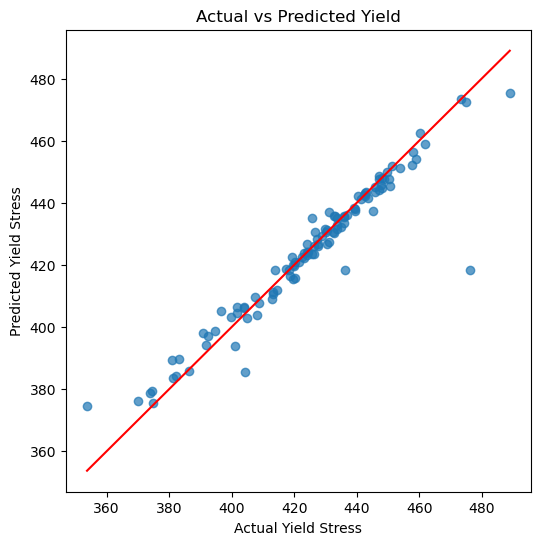

In [20]:
plt.figure(figsize=(6,6))

plt.scatter(y_test, y_pred, alpha=0.7)

plt.xlabel("Actual Yield Stress")
plt.ylabel("Predicted Yield Stress")
plt.title("Actual vs Predicted Yield")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='red'
)

plt.show()

In [21]:
importance = rf_model.feature_importances_

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)

feature_importance

,Feature,Importance
2,N,0.632413
1,V,0.259472
3,HeatInput,0.069737
0,D,0.038378


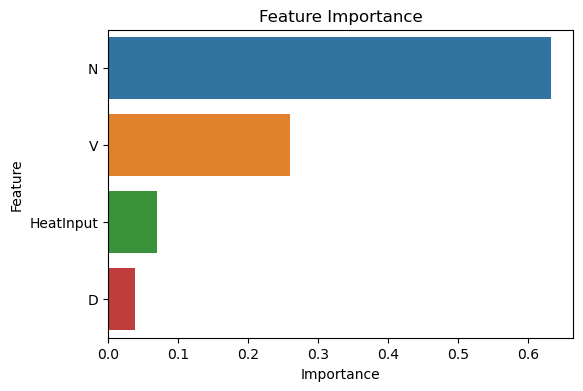

In [22]:
plt.figure(figsize=(6,4))

sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_importance
)

plt.title("Feature Importance")
plt.show()

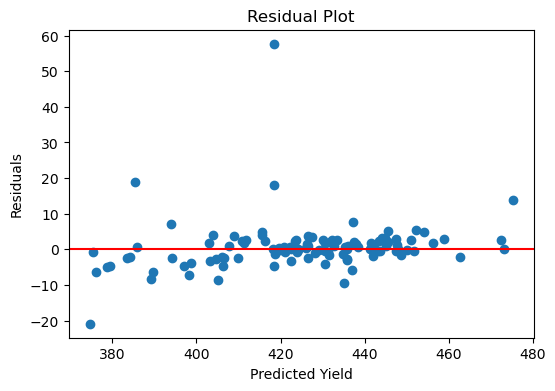

In [23]:
residuals = y_test - y_pred

plt.figure(figsize=(6,4))

plt.scatter(y_pred, residuals)

plt.axhline(0, color='red')

plt.xlabel("Predicted Yield")
plt.ylabel("Residuals")

plt.title("Residual Plot")

plt.show()

In [24]:
import joblib

joblib.dump(rf_model, "fsw_random_forest_model.pkl")

['fsw_random_forest_model.pkl']